# Portfolio Analysis with Quantstats

In [1]:
import quantstats as qs

In [2]:
qs.utils.download_returns('AAPL')

Date
1980-12-12    0.000000
1980-12-15   -0.052170
1980-12-16   -0.073398
1980-12-17    0.024751
1980-12-18    0.028992
                ...   
2026-06-30    0.027046
2026-07-01    0.017349
2026-07-02    0.048407
2026-07-06    0.013058
2026-07-07   -0.006397
Name: Close, Length: 11482, dtype: float64

In [3]:
returns = qs.utils.download_returns('AAPL')

In [5]:
benchmark = qs.utils.download_returns('SPY')

In [6]:
qs.stats.sharpe(returns)

np.float64(0.626913295482434)

In [7]:
qs.stats.cagr(returns)

np.float64(0.1934906514772059)

In [8]:
qs.stats.max_drawdown(returns)

np.float64(-0.8180144122346075)

In [10]:
qs.stats.greeks(returns,benchmark).to_dict()

{'beta': 1.1053576201334843, 'alpha': 0.17681981192746293}

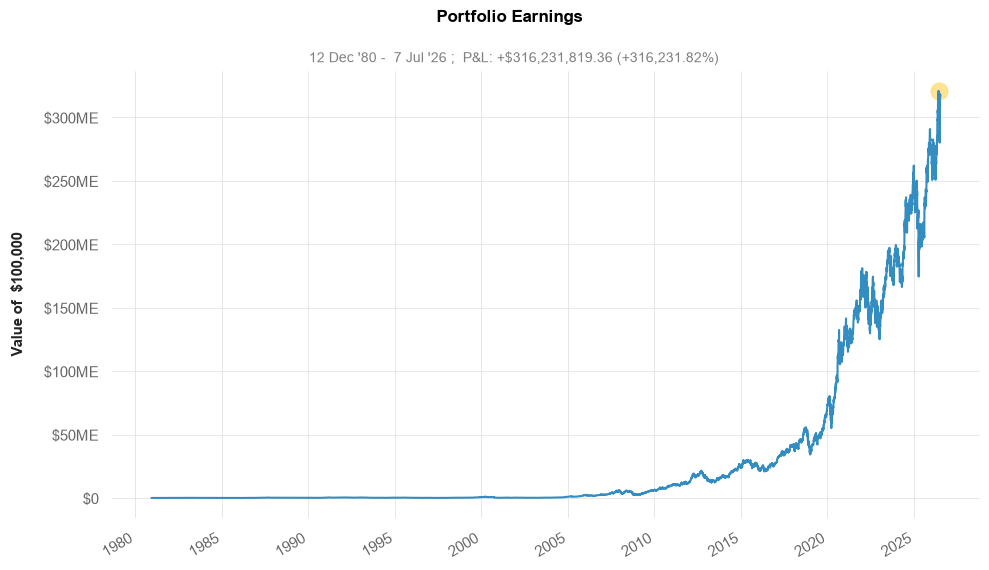

In [11]:
qs.plots.earnings(returns)

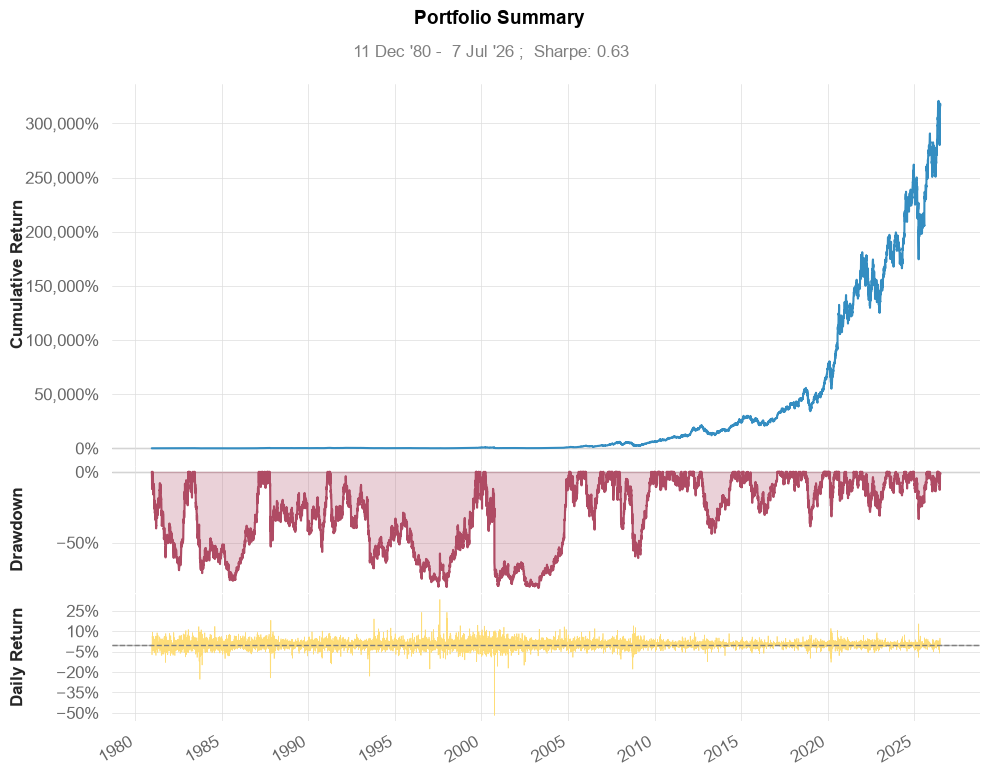

In [12]:
qs.plots.snapshot(returns)

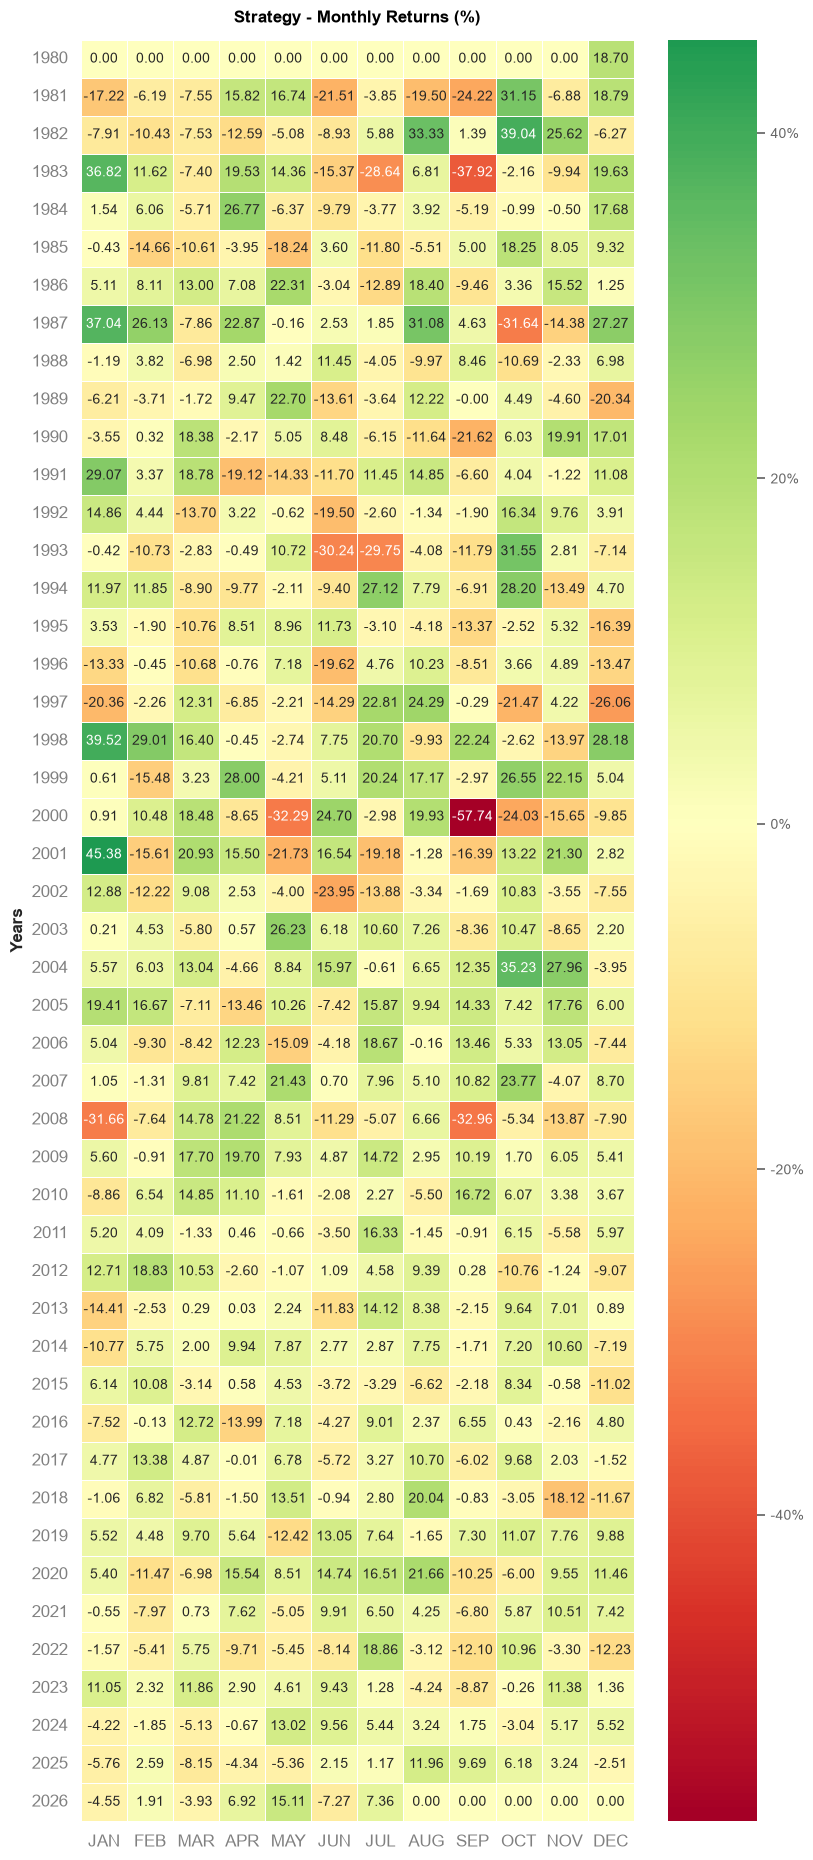

In [13]:
qs.plots.monthly_heatmap(returns)

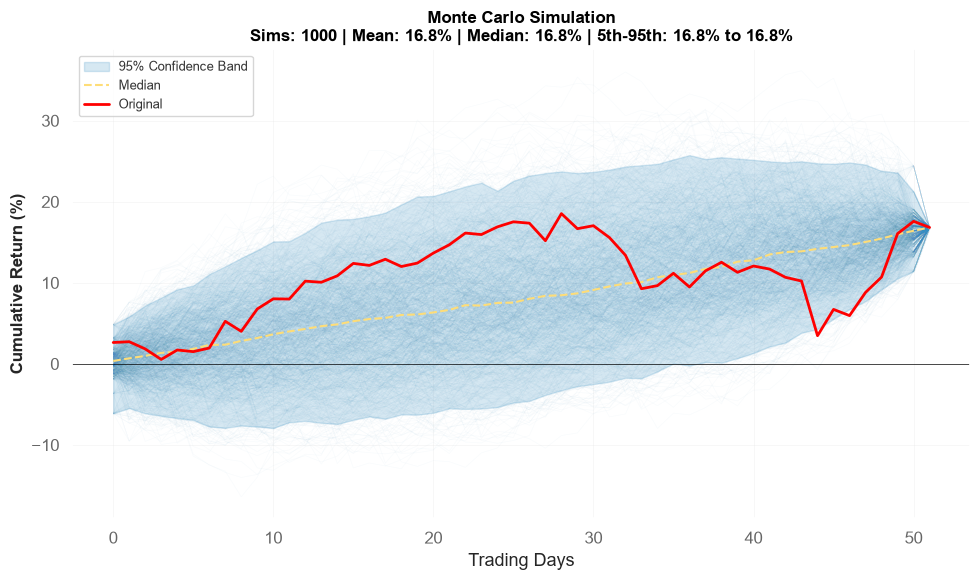

In [14]:
qs.plots.montecarlo(returns.tail(52))

In [16]:
qs.reports.html(returns,benchmark, title='AAPL vs S%P500', output='report.html')


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               1993-02-01   1993-02-01
End Period                 2026-07-07   2026-07-07
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       99.0%

Cumulative Return          3,000.83%    72,337.91%
CAGR﹪                     10.83%       21.8%

Sharpe                     0.65         0.68
Prob. Sharpe Ratio         99.99%       100.0%
Smart Sharpe               0.63         0.67
Sortino                    0.92         1.01
Smart Sortino              0.9          0.98
Sortino/√2                 0.65         0.71
Smart Sortino/√2           0.64         0.7
Omega                      1.13         1.14

Max Drawdown               -55.19%      -81.8%
Max DD Date                2009-03-09   20

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2000-03-23,2003-04-17,2005-01-25,1770,-81.801441,-80.858216
2,1993-02-02,1997-12-23,1999-08-10,2381,-78.068637,-76.373361
3,2007-12-31,2009-01-20,2009-10-20,660,-60.866731,-58.409642
4,2012-09-20,2013-04-19,2014-07-11,660,-43.797191,-42.332865
5,2006-01-17,2006-07-14,2006-11-15,303,-40.799158,-38.193699


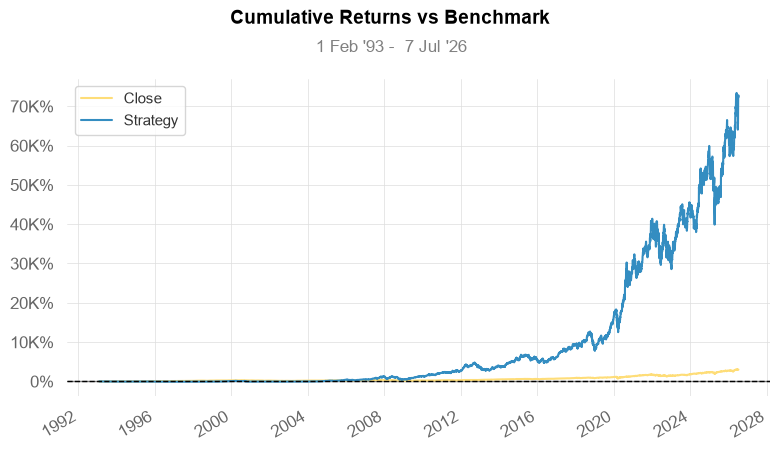

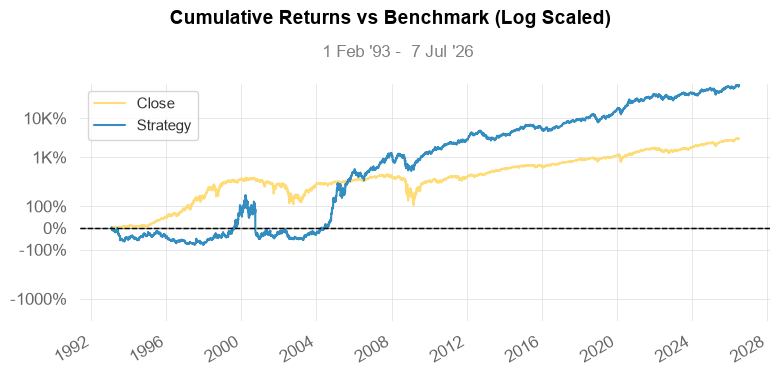

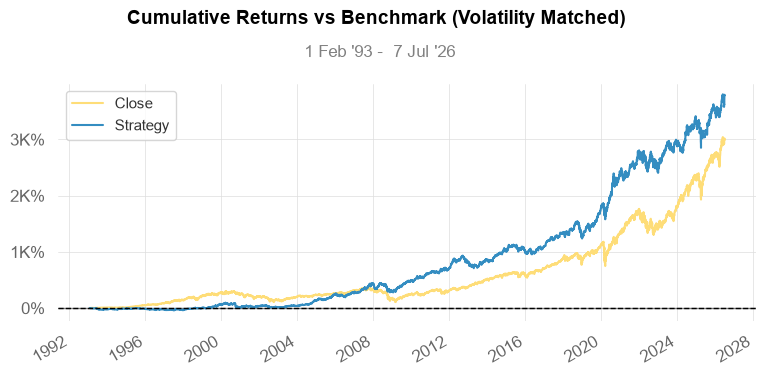

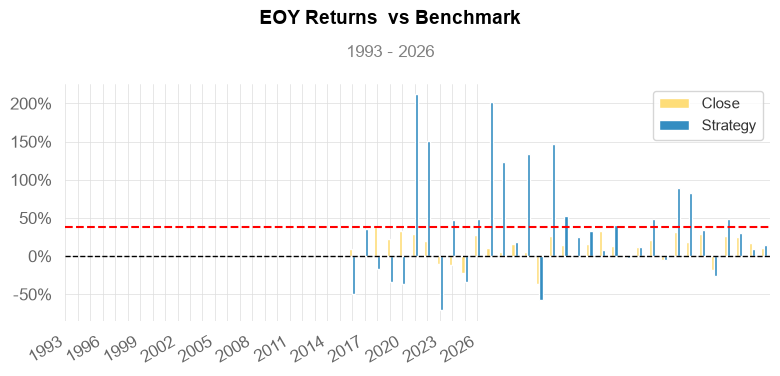

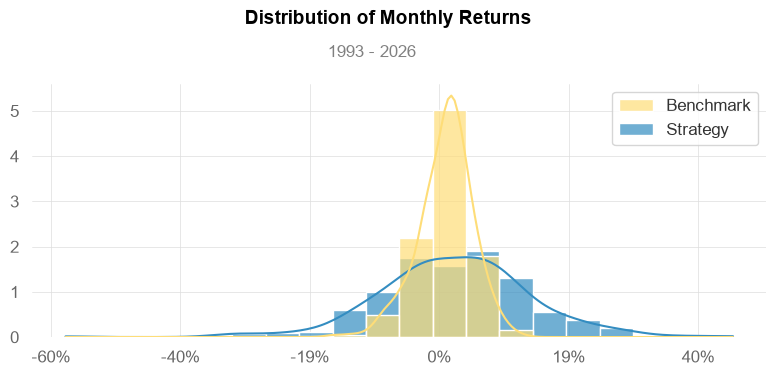

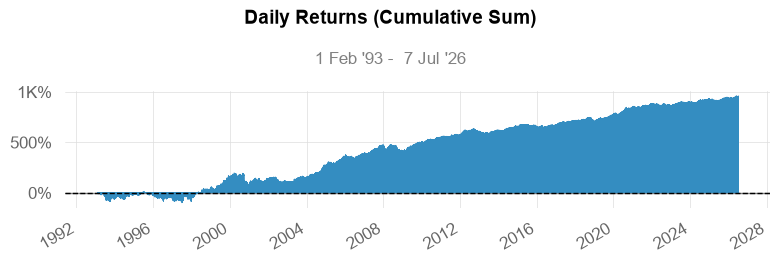

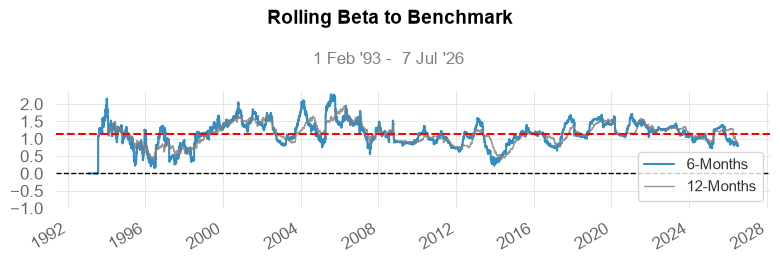

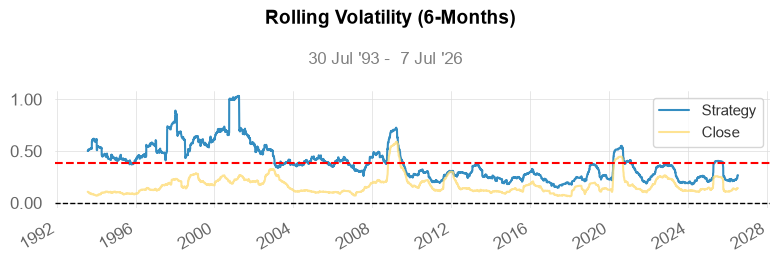

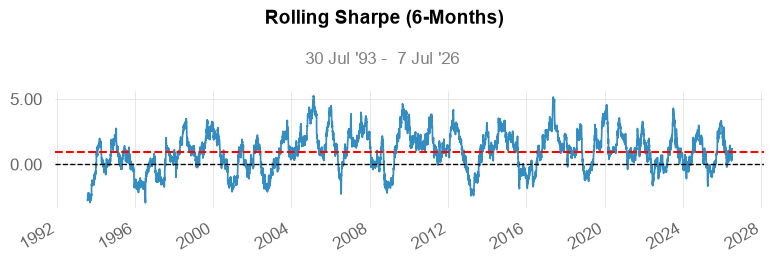

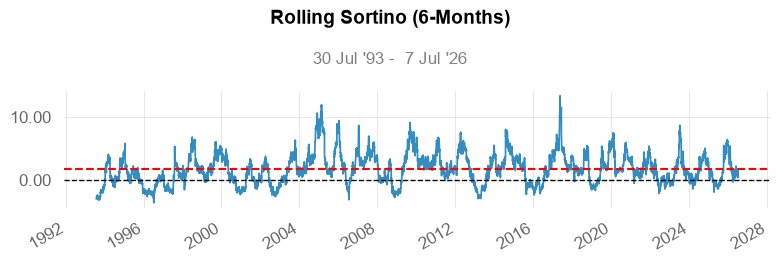

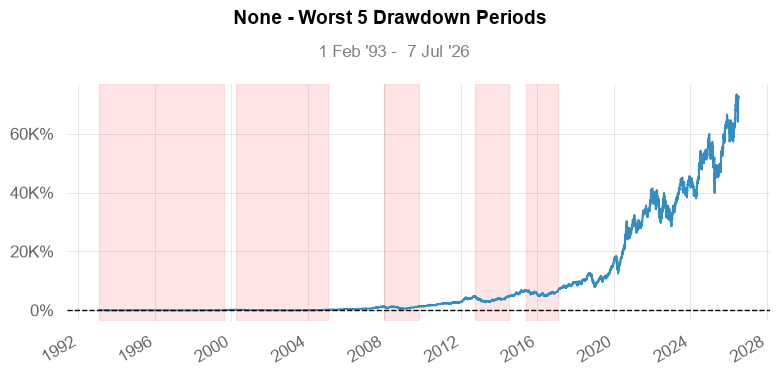

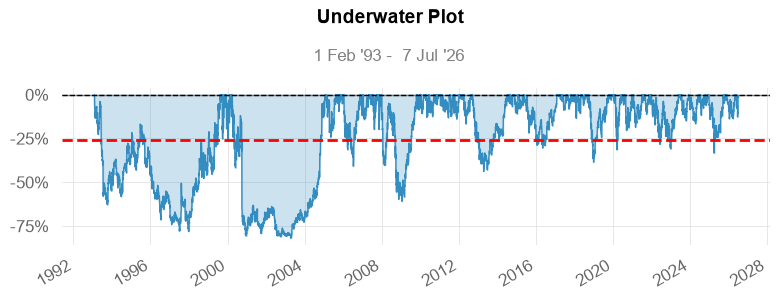

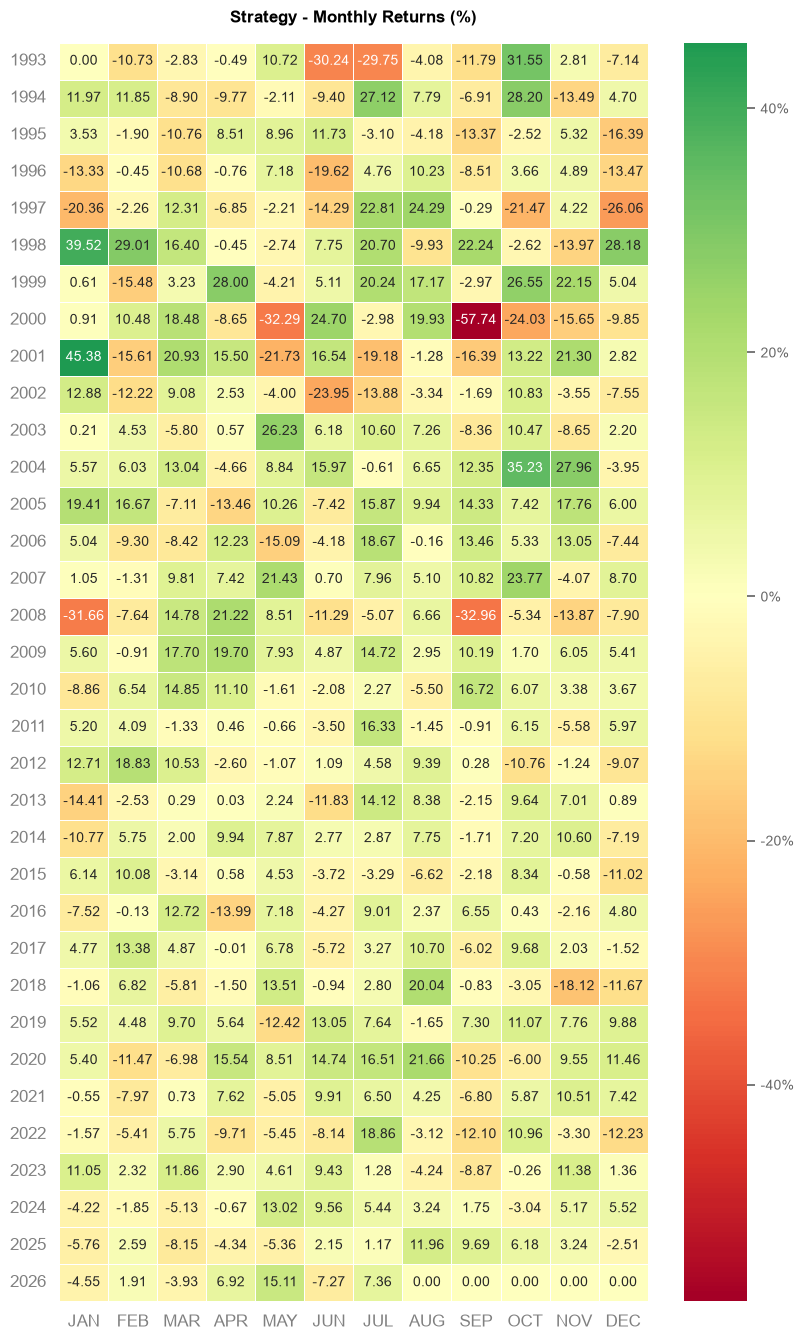

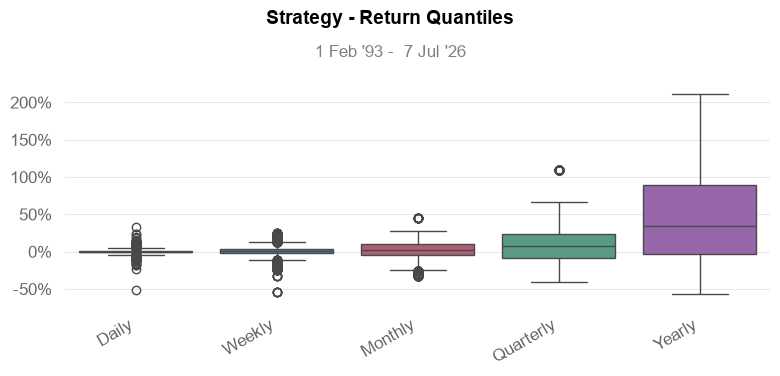

In [17]:
qs.reports.full(returns,benchmark)

## Personal Portfolio

In [18]:
import pandas as pd

In [29]:
portfolio_weights = {'AAPL':0.2,
                     'NVDA':0.3,
                     'TSLA':0.15,
                     'MSFT':0.2,
                     'META':0.15}

In [30]:
returns = pd.DataFrame({ticker: qs.utils.download_returns(ticker) for ticker in portfolio_weights.keys()}).dropna()

In [31]:
returns

,AAPL,NVDA,TSLA,MSFT,META
Date,,,,,
2012-05-18,0.000491,-0.045060,-0.035352,-0.015141,0.000000
2012-05-21,0.058260,0.017384,0.043904,0.016399,-0.109862
2012-05-22,-0.007679,-0.012205,0.070559,0.000336,-0.089039
2012-05-23,0.024400,0.024711,0.007143,-0.021842,0.032258
2012-05-24,-0.009184,-0.026527,-0.023855,-0.001374,0.032187
...,...,...,...,...,...
2026-06-30,0.027046,0.026260,0.021270,0.012074,0.001226
2026-07-01,0.017349,-0.012544,0.011174,0.030186,0.088090
2026-07-02,0.048407,-0.013918,-0.074888,0.016160,-0.048963


In [34]:
portfolio = (returns * pd.Series(portfolio_weights)).sum(axis=1).rename('Portfolio')

In [35]:
portfolio

Date
2012-05-18   -0.021751
2012-05-21    0.010253
2012-05-22   -0.007902
2012-05-23    0.013835
2012-05-24   -0.008820
                ...   
2026-06-30    0.019077
2026-07-01    0.020633
2026-07-02   -0.009840
2026-07-06    0.016309
2026-07-07   -0.000284
Name: Portfolio, Length: 3552, dtype: float64

In [36]:
sp500 = qs.utils.download_returns('SPY').rename('SP500')

In [39]:
qs.reports.html(portfolio, sp500, title='Personal Portfolio vs S&P500', output='portfolio_report.html')

## Vectorized Backtesting

In [40]:
import talib as ta
import yfinance as yf

In [45]:
price = yf.Ticker('AAPL').history(start='2010-01-01')['Close']
price.index = price.index.tz_localize(None)

In [46]:
price

Date
2010-01-04      6.406482
2010-01-05      6.417557
2010-01-06      6.315478
2010-01-07      6.303801
2010-01-08      6.345710
                 ...    
2026-06-30    289.359985
2026-07-01    294.380005
2026-07-02    308.630005
2026-07-06    312.660004
2026-07-07    310.660004
Name: Close, Length: 4151, dtype: float64

In [47]:
macd, signal, _ = ta.MACD(price)

In [48]:
macd

Date
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
                ...   
2026-06-30   -2.776065
2026-07-01   -2.248011
2026-07-02   -0.671923
2026-07-06    0.892042
2026-07-07    1.947661
Length: 4151, dtype: float64

In [49]:
position = (macd > signal).shift(fill_value=False)

In [50]:
daily = price.pct_change().fillna(0)

In [52]:
strategy = (daily * position).rename('MACD')

In [53]:
strategy

Date
2010-01-04    0.000000
2010-01-05    0.000000
2010-01-06   -0.000000
2010-01-07   -0.000000
2010-01-08    0.000000
                ...   
2026-06-30    0.000000
2026-07-01    0.000000
2026-07-02    0.000000
2026-07-06    0.013058
2026-07-07   -0.006397
Name: MACD, Length: 4151, dtype: float64

In [54]:
buy_hold = daily.rename('Buy and Hold')

In [55]:
qs.reports.html(strategy, buy_hold, title='MACD vs BuyHold', output='macd.html')